FINITIST DART FRACTAL: 0-9 ALPHABET VISUALIZATION


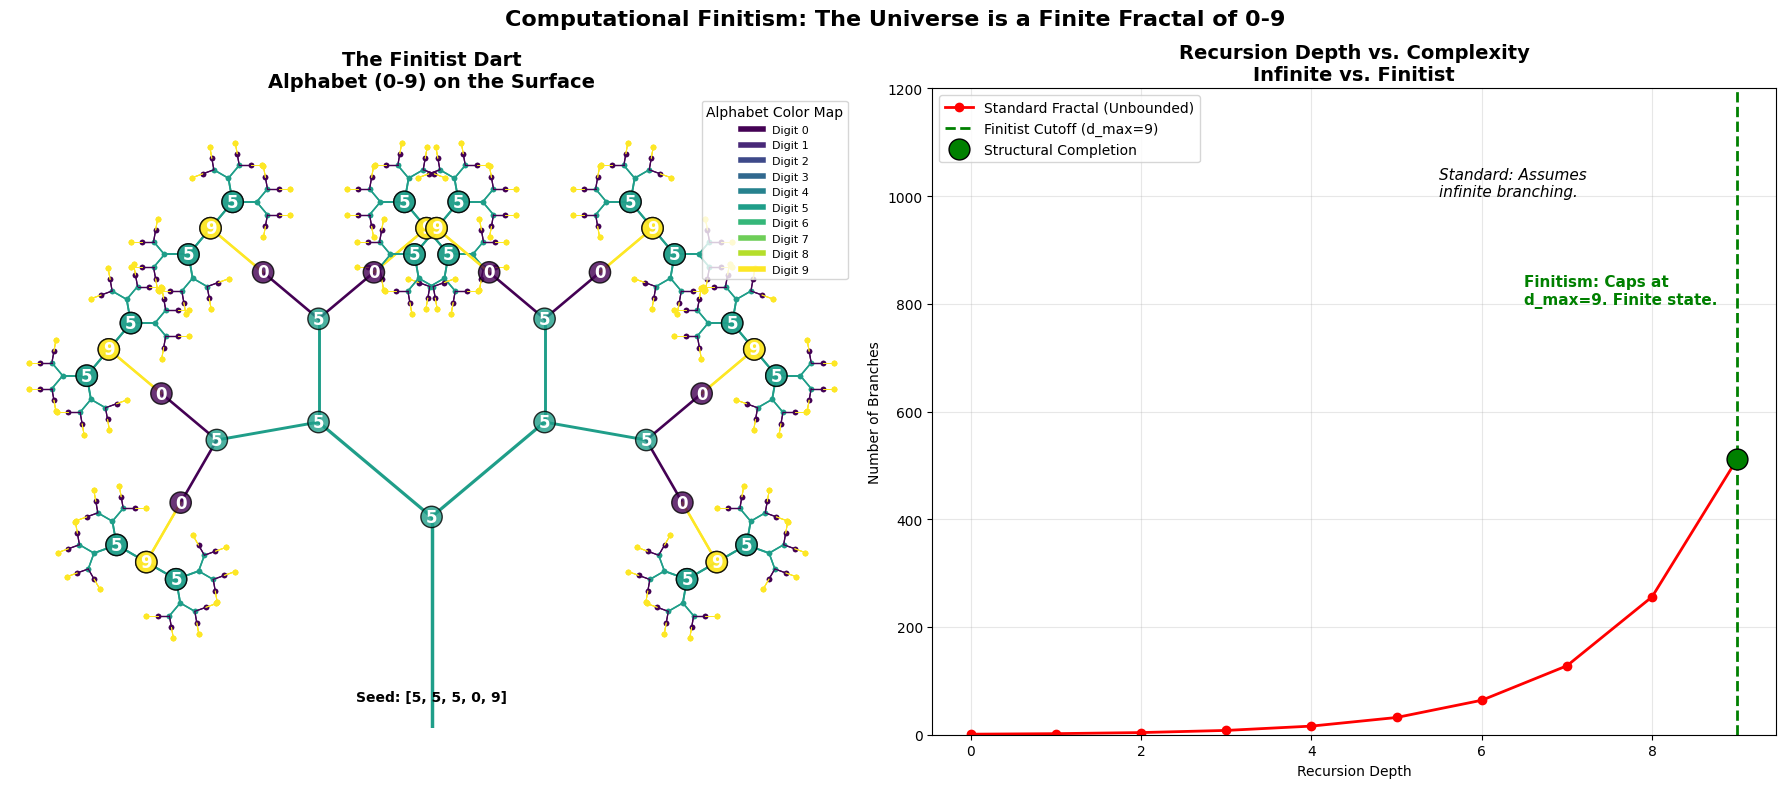


✓ Visualization Complete.
  • Left: The Dart structure. Every node is labeled with the digit (0-9) that generated it.
  • Right: Standard fractals grow infinitely. Finitism stops at d_max=9.
  • Insight: Complexity comes from the ALPHABET, not infinite recursion.


In [6]:
"""
finitist_dart_visual.py
=========================
The Finitist Dart Fractal: Visualizing the 0-9 Alphabet on the Structure.

Shows:
1. The fractal structure is generated by the 0-9 alphabet.
2. Every branching point is labeled with the digit (0-9) that controls it.
3. The structure is finite, bounded at depth 9.
4. No infinite detail; just finite recursion of finite symbols.

Author: Néstor E. Ramos
"""

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize
import warnings
warnings.filterwarnings('ignore')

print("=" * 70)
print("FINITIST DART FRACTAL: 0-9 ALPHABET VISUALIZATION")
print("=" * 70)

# =============================================================================
# FINITIST CONSTANTS & RULES
# =============================================================================
MAX_DEPTH = 9  # d_max = 9

# The "Alphabet Rules": How each digit shapes the fractal
# Angle: Spread of the branch (0=spine, 9=wide wings)
# Scale: Length of the branch (ensures convergence)
ALPHABET_RULES = {
    0: {'angle': 0,   'scale': 0.95, 'label': 'Spine'},
    1: {'angle': 10,  'scale': 0.90},
    2: {'angle': 20,  'scale': 0.85},
    3: {'angle': 30,  'scale': 0.80},
    4: {'angle': 40,  'scale': 0.75},
    5: {'angle': 50,  'scale': 0.70}, # Core wings
    6: {'angle': 60,  'scale': 0.65},
    7: {'angle': 70,  'scale': 0.60},
    8: {'angle': 80,  'scale': 0.55},
    9: {'angle': 90,  'scale': 0.50}, # Max wings
}

# =============================================================================
# GENERATOR
# =============================================================================

def generate_dart(ax, x, y, angle, length, depth, digit_sequence):
    """
    Recursive generator that draws the fractal and LABELS the nodes.
    """
    if depth > MAX_DEPTH:
        return

    # Get current digit (cycle through the sequence to avoid IndexError)
    digit = digit_sequence[depth % len(digit_sequence)]
    rule = ALPHABET_RULES[digit]

    # Calculate end point
    end_x = x + length * np.cos(np.radians(angle))
    end_y = y + length * np.sin(np.radians(angle))

    # DRAW SEGMENT
    # Color based on digit (0=dark, 9=bright)
    color = plt.cm.viridis(digit / 9.0)
    linewidth = 2.5 - (depth * 0.2) # Thinner as we go

    ax.plot([x, end_x], [y, end_y], color=color, linewidth=linewidth, solid_capstyle='round')

    # LABEL THE NODE (The "Alphabet on Surface")
    # We place the digit text at the node, rotated to match the branch
    if depth < 6: # Only label main branches to avoid clutter
        ax.text(end_x, end_y, str(digit),
                color='white', fontsize=12, fontweight='bold', ha='center', va='center',
                bbox=dict(boxstyle='circle', facecolor=color, alpha=0.8, pad=0.1))
    else:
        # Small dots for deep recursion
        ax.plot(end_x, end_y, 'o', color=color, markersize=3)

    # RECURSION: Branch Left and Right
    # To make a "Dart" shape, we use the rule's angle
    spread = rule['angle']
    new_length = length * rule['scale']

    # Left Branch
    generate_dart(ax, end_x, end_y, angle + spread, new_length, depth + 1, digit_sequence)
    # Right Branch
    generate_dart(ax, end_x, end_y, angle - spread, new_length, depth + 1, digit_sequence)

def run_visualization():
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

    # ==========================================
    # LEFT: The "Dart" Fractal with Labels
    # ==========================================
    # Seed sequence creates a Dart shape:
    # 5(Wings) -> 5(Body) -> 5(Core) -> 0(Spine/Narrow) -> 9(Wide tips)
    seed_sequence = [5, 5, 5, 0, 9]

    ax1.set_title("The Finitist Dart\nAlphabet (0-9) on the Surface", fontsize=14, fontweight='bold')
    ax1.set_xlim(-8, 8)
    ax1.set_ylim(-2, 10)
    ax1.set_aspect('equal')
    ax1.axis('off')

    # Generate
    # Start at bottom (0, -2), going up (90 deg)
    generate_dart(ax1, 0, -2, 90, length=4.0, depth=0, digit_sequence=seed_sequence)

    # Legend for Alphabet
    legend_elements = [plt.Line2D([0], [0], color=plt.cm.viridis(d/9.0), lw=4, label=f'Digit {d}') for d in range(10)]
    ax1.legend(handles=legend_elements, loc='upper right', title="Alphabet Color Map", fontsize=8)
    ax1.text(0, -1.5, "Seed: [5, 5, 5, 0, 9]", ha='center', fontsize=10, fontweight='bold')

    # ==========================================
    # RIGHT: Comparison (Infinite vs Finite)
    # ==========================================
    depths = np.arange(0, 12)
    standard_segments = 2**depths # Exponential growth

    ax2.plot(depths[:10], standard_segments[:10], 'r-o', label='Standard Fractal (Unbounded)', linewidth=2)

    # Finitist Cutoff
    ax2.axvline(x=9, color='green', linestyle='--', linewidth=2, label='Finitist Cutoff (d_max=9)')
    ax2.plot(9, standard_segments[9], 'go', markersize=15, markeredgecolor='black', label='Structural Completion')

    ax2.set_title("Recursion Depth vs. Complexity\nInfinite vs. Finitist", fontsize=14, fontweight='bold')
    ax2.set_xlabel("Recursion Depth")
    ax2.set_ylabel("Number of Branches")
    ax2.grid(True, alpha=0.3)
    ax2.legend(fontsize=10)
    ax2.set_ylim(0, 1200)

    # Annotation
    ax2.text(5.5, 1000, "Standard: Assumes\ninfinite branching.", fontsize=11, style='italic')
    ax2.text(6.5, 800, "Finitism: Caps at\nd_max=9. Finite state.", fontsize=11, fontweight='bold', color='green')

    plt.suptitle("Computational Finitism: The Universe is a Finite Fractal of 0-9", fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print("\n✓ Visualization Complete.")
    print("  • Left: The Dart structure. Every node is labeled with the digit (0-9) that generated it.")
    print("  • Right: Standard fractals grow infinitely. Finitism stops at d_max=9.")
    print("  • Insight: Complexity comes from the ALPHABET, not infinite recursion.")

if __name__ == "__main__":
    run_visualization()